## Demonstrating a "basic" user flow with the current abstractions of a qutip-qoc rewrite

**System type**: closed, zero-drift, one control (x-rotation)

**Objective**: state transfer

**Algorithm**: GRAPE

## Imports

In [3]:
from qoc.systems import ControlledSystem
from qoc.objectives import StateTransfer
from qoc.pulse import PiecewiseConstant
from qoc.problem import OptimalControlProblem
from qoc.algorithms import GRAPE

In [2]:
import qutip as qt
import numpy as np

## Describe system dynamics

In [9]:
# Drift Hamiltonian
H0 = 0 * qt.sigmax()
# Control Hamiltonian(s)
H_controls = [qt.sigmax()]
# Define the system, explicitly specify its type
system = ControlledSystem(H0=H0, H_controls=H_controls, kind="closed")

## Define control objective

Together with necessary initial conditions and a target

In [36]:
initial_state = qt.basis(2, 0)
target_state = qt.basis(2, 1)
objective = StateTransfer(initial_state, target_state) # For such composite classes, 
# it would be nice to have a kind of .info() methods giving a user-friendly description

With a state transfer task, we are lucky to be able to visualize those on the Bloch sphere:

In [16]:
b = qt.Bloch()
b.add_states([initial_state, target_state])

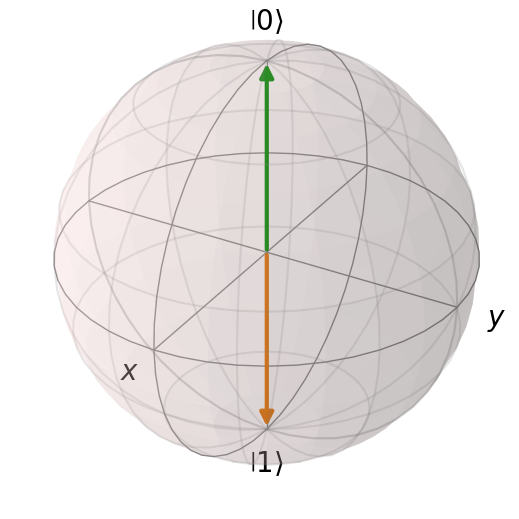

In [25]:
b # green - initial, red (?)  - target

## System and objective define an optimal control problem definition

In [43]:
control_problem = OptimalControlProblem(system, objective)

## Meta-step: decide on the algorithm

## With the algorithm in mind, define an appropriate pulse parameterisation

For GRAPE, it's piecewise-constant. Hence, select corresponding parameters.

In [47]:
# Number of time steps/slices
N = 10
# Total simulation time
T = 100
# Number of controls
K = system.dynamics.n_controls # TODO: encapsulate this level of detail 
# (dynamics attributes by adding more high level properties-wrappers)
# Initial pulse vector
initial_pulse = np.random.uniform(-0.1, 0.1, (K, N)) # (will be used upon calling Algorithm.solve)
times = np.linspace(0, T, N, endpoint=False)
parameterisation = PiecewiseConstant(K, times=times)